In [ ]:
!pip install "tensorflow>=2.0.0"

In [ ]:
!pip install --upgrade tensorflow-hub

In [ ]:
import numpy as np
import cv2

import PIL.Image as Image
import os

import matplotlib.pylab as plt

import tensorflow as tf
import tensorflow_hub as hub

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential

In [ ]:
IMAGE_SHAPE = (224, 224)

# Define the input layer
inputs = tf.keras.Input(shape=IMAGE_SHAPE + (3,))

# Use tf.keras.applications.MobileNetV2 directly for classification
# This bypasses tensorflow_hub.KerasLayer, which seems to be causing the symbolic tensor error.
# We load the MobileNetV2 model pre-trained on ImageNet, including the top classification layer.
base_model = tf.keras.applications.MobileNetV2(
    input_shape=IMAGE_SHAPE + (3,),
    include_top=True, # Include the classification layer
    weights='imagenet' # Use pre-trained ImageNet weights
)

# Set the base model as non-trainable if you only want to use it as a feature extractor
base_model.trainable = False

# Apply the base model to the inputs
outputs = base_model(inputs)

# Create the model using the Functional API
classifier = tf.keras.Model(inputs=inputs, outputs=outputs)

14536120/14536120 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [ ]:
dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"
data_dir = tf.keras.utils.get_file('flower_photos', origin=dataset_url,  cache_dir='.', untar=True)

228813984/228813984 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


In [ ]:
data_dir

'./datasets/flower_photos'

In [ ]:
import pathlib
data_dir = pathlib.Path(data_dir)
data_dir

PosixPath('datasets/flower_photos')

In [ ]:
data_dir = data_dir / 'flower_photos'
print(data_dir)
list(data_dir.glob('*/*.jpg'))[:5]

datasets/flower_photos/flower_photos


[PosixPath('datasets/flower_photos/flower_photos/daisy/10559679065_50d2b16f6d.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/daisy/3711892138_b8c953fdc1_z.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/daisy/4301689054_20519e5b68.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/daisy/7630517248_98fb8bee1f_n.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/daisy/4820415253_15bc3b6833_n.jpg')]

In [ ]:
image_count = len(list(data_dir.glob('*/*.jpg')))
print(image_count)

3670


In [ ]:
roses = list(data_dir.glob('roses/*'))
roses[:5]

[PosixPath('datasets/flower_photos/flower_photos/roses/2183357362_4b4da4b6b5.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/roses/5398974188_799753449c.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/roses/4279990882_031482f8b6_n.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/roses/22982871191_ec61e36939_n.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/roses/3630246240_4fee9a33db.jpg')]

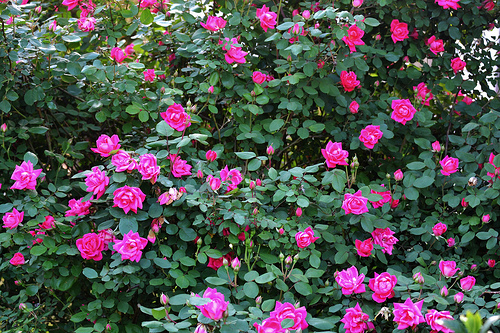

In [ ]:
import PIL
#import PIL.Image as Image
PIL.Image.open(str(roses[99]))

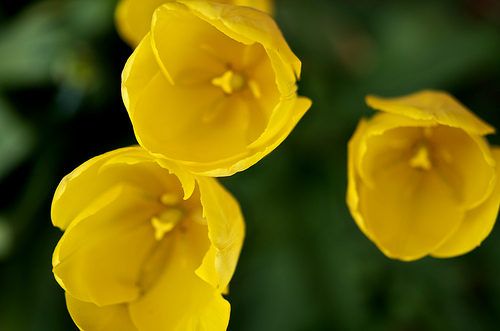

In [ ]:
tulips = list(data_dir.glob('tulips/*'))
PIL.Image.open(str(tulips[8]))

In [ ]:
flowers_images_dict = {
    'roses': list(data_dir.glob('roses/*')),
    'daisy': list(data_dir.glob('daisy/*')),
    'dandelion': list(data_dir.glob('dandelion/*')),
    'sunflowers': list(data_dir.glob('sunflowers/*')),
    'tulips': list(data_dir.glob('tulips/*')),
}
flowers_labels_dict = {
    'roses': 0,
    'daisy': 1,
    'dandelion': 2,
    'sunflowers': 3,
    'tulips': 4,
}

In [ ]:
X, y = [], []

for flower_name, images in flowers_images_dict.items():
    for image in images:
        img = cv2.imread(str(image))
        resized_img = cv2.resize(img,(224,224))
        X.append(resized_img)
        y.append(flowers_labels_dict[flower_name])

In [ ]:
X = np.array(X)
y = np.array(y)

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

In [ ]:
X_train_scaled = X_train / 255
X_test_scaled = X_test / 255

In [ ]:
X_train_scaled[0].shape

(224, 224, 3)

In [ ]:
feature_extractor_model = "https://tfhub.dev/google/tf2-preview/mobilenet_v2/feature_vector/4" # This string is no longer directly used for model creation

# Define the input layer
inputs = tf.keras.Input(shape=(224, 224, 3))

# Use tf.keras.applications.MobileNetV2 directly as a feature extractor
# by setting include_top=False to exclude the classification head.
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False, # Important: Exclude the classification layer
    weights='imagenet' # Use pre-trained ImageNet weights
)

# Set the base model as non-trainable
base_model.trainable = False

# Apply the base model to the inputs to get the feature vector
x = base_model(inputs)

# Flatten the output of the base model as it's typically a 4D tensor (batch, height, width, channels)
# before connecting to a Dense layer.
x = tf.keras.layers.GlobalAveragePooling2D()(x)

num_of_flowers = 5

# Add a dense classification layer on top of the feature extractor
outputs = tf.keras.layers.Dense(num_of_flowers)(x)

# Create the model using the Functional API
model = tf.keras.Model(inputs=inputs, outputs=outputs)

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 5)              │         6,405 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,264,389 (8.64 MB)

 Trainable params: 6,405 (25.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
model.compile(
  optimizer="adam",
  loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
  metrics=['acc'])

model.fit(X_train_scaled, y_train, epochs=5)

Epoch 1/5
86/86 ━━━━━━━━━━━━━━━━━━━━ 124s 1s/step - acc: 0.6850 - loss: 0.8436
Epoch 2/5
86/86 ━━━━━━━━━━━━━━━━━━━━ 147s 1s/step - acc: 0.8488 - loss: 0.4405
Epoch 3/5
86/86 ━━━━━━━━━━━━━━━━━━━━ 139s 1s/step - acc: 0.8768 - loss: 0.3488
Epoch 4/5
86/86 ━━━━━━━━━━━━━━━━━━━━ 115s 1s/step - acc: 0.9004 - loss: 0.2975
Epoch 5/5
86/86 ━━━━━━━━━━━━━━━━━━━━ 151s 1s/step - acc: 0.9237 - loss: 0.2554


In [ ]:
model.evaluate(X_test_scaled,y_test)

29/29 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - acc: 0.8508 - loss: 0.4325


[0.4324633479118347, 0.8507625460624695]

In [ ]:
pre = model.predict(np.expand_dims(X_test_scaled[0], axis=0))
pre

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 246ms/step


array([[-0.42857358, -1.3552693 , -2.512778  , -1.7790004 , -4.2000456 ]],
      dtype=float32)

In [ ]:
maximum = np.argmax(pre)
maximum

np.int64(0)

In [ ]:
predicted_class_index = maximum

# Reverse the dictionary to map index to class name
index_to_class = {v: k for k, v in flowers_labels_dict.items()}

predicted_class_name = index_to_class[predicted_class_index]
print(f"The predicted class is: {predicted_class_name}")

The predicted class is: roses


In [ ]:
y_test[0]

np.int64(1)